# Rollout simple des modeles du papier sur le maillage regulier

Notebook minimal pour :
- charger un checkpoint du papier
- reutiliser les stats de normalisation du checkpoint
- faire un unrolling auto-regressif simple
- obtenir quelques metriques et cartes sur le maillage regulier

Par defaut, le notebook est regle sur le modele que tu as indique comme le bon :
- `Experiment 6`
- `ckpt_dir = /work/m24046/m24046mrcr/paper/Experience10/Seed0/`
- `epoch = 900`
- `use_q_feature = True`
- `mesh = multimesh`


In [1]:
import glob
import math
import sys
from pathlib import Path

import dgl
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().resolve()
if not (ROOT / "python").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from python.CustomMeshGraphNet import MeshGraphNet
from python.create_dgl_dataset import TelemacDataset, TelemacDatasetWithQ, add_mesh_info
from python.python_code.data_manip.extraction.telemac_file import TelemacFile
from modulus.launch.utils import load_checkpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [7]:
MODEL_CONFIG = {
    "name": "Experiment 4",
    "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience2/Seed0/",
    "epoch": 900,
    "use_q_feature": False,
    "mesh": "multimesh",
    "num_input_features": 9,
    "num_output_features": 3,
    "num_edge_features": 3,
    "mp_layers": 10,
    "do_concat_trick": True,
    "num_processor_checkpoint_segments": 0,
    "dt_seconds": 1800.0,
}

REGULAR_MESH_SLF = "/work/m24046/m24046mrcr/Aube/Aube_T1_regulier20m.slf"
REGULAR_BASE_BIN = "/work/m24046/m24046mrcr/Aube/Test_regular_T1/Aube_regular_base.bin"
REGULAR_DYNAMIC_GLOB = "/work/m24046/m24046mrcr/Aube/Test_regular_T1/*_interpolated.pkl"

# Si tous les chunks correspondent a la meme crue, mets ici un seul .liq.
# Le notebook le repetera automatiquement sur tous les fichiers dynamiques.
REGULAR_HYDRO_FILE = "/work/m24046/m24046mrcr/Aube/MODELE_AUBE_T1_T2_Q5_Q30_Q100/12_T1_V9_Topo3_KV5_Q100/T1_Q100_V1.liq"


MAX_DYNAMIC_FILES = 1
CHECKPOINT_EPOCH = MODEL_CONFIG["epoch"]

UNROLL_STEPS = 12
OVERLAP = UNROLL_STEPS
MAX_SEQUENCES = 8

SEQUENCE_TO_PLOT = 0
PLOT_STEP = 12
WET_THRESHOLD_M = 0.05
FIGSIZE = (16, 10)


In [8]:
def require_existing(path_like, label):
    path = Path(path_like).expanduser()
    if not path.exists():
        raise FileNotFoundError(f"{label} introuvable: {path}")
    return path

regular_mesh_path = require_existing(REGULAR_MESH_SLF, "REGULAR_MESH_SLF")
regular_base_path = require_existing(REGULAR_BASE_BIN, "REGULAR_BASE_BIN")
ckpt_dir = require_existing(MODEL_CONFIG["ckpt_dir"], "CKPT_DIR")

dynamic_files = [Path(p) for p in sorted(glob.glob(REGULAR_DYNAMIC_GLOB))]
if MAX_DYNAMIC_FILES is not None:
    dynamic_files = dynamic_files[:MAX_DYNAMIC_FILES]
if not dynamic_files:
    raise FileNotFoundError(f"Aucun fichier trouve pour REGULAR_DYNAMIC_GLOB: {REGULAR_DYNAMIC_GLOB}")
dynamic_files = [require_existing(path, f"DYNAMIC_FILE[{i}]") for i, path in enumerate(dynamic_files)]

hydro_files = []
if MODEL_CONFIG["use_q_feature"]:
    if REGULAR_HYDRO_FILES:
        hydro_files = [require_existing(path, f"HYDRO_FILE[{i}]") for i, path in enumerate(REGULAR_HYDRO_FILES)]
    elif REGULAR_HYDRO_FILE:
        hydro_path = require_existing(REGULAR_HYDRO_FILE, "REGULAR_HYDRO_FILE")
        hydro_files = [hydro_path for _ in dynamic_files]
    else:
        raise ValueError(
            "Ce modele utilise Q. Renseigne REGULAR_HYDRO_FILE ou REGULAR_HYDRO_FILES."
        )

    if len(hydro_files) != len(dynamic_files):
        raise ValueError(
            f"Nombre de hydro_files ({len(hydro_files)}) different du nombre de dynamic_files ({len(dynamic_files)})."
        )

print("model:", MODEL_CONFIG["name"])
print("ckpt dir:", ckpt_dir)
print("checkpoint epoch:", CHECKPOINT_EPOCH)
print("use_q_feature:", MODEL_CONFIG["use_q_feature"])
print("mesh type (training):", MODEL_CONFIG["mesh"])
print("regular mesh:", regular_mesh_path)
print("regular base:", regular_base_path)
print("dynamic files:")
for path in dynamic_files:
    print(" -", path)
if hydro_files:
    print("hydro files:")
    for path in hydro_files:
        print(" -", path)


model: Experiment 4
ckpt dir: /work/m24046/m24046mrcr/paper/Experience2/Seed0
checkpoint epoch: 900
use_q_feature: False
mesh type (training): multimesh
regular mesh: /work/m24046/m24046mrcr/Aube/Aube_T1_regulier20m.slf
regular base: /work/m24046/m24046mrcr/Aube/Test_regular_T1/Aube_regular_base.bin
dynamic files:
 - /work/m24046/m24046mrcr/Aube/Test_regular_T1/Aube_regular_0_0-80_interpolated.pkl


In [9]:
def build_model(cfg):
    model = MeshGraphNet(
        cfg["num_input_features"],
        cfg["num_edge_features"],
        cfg["num_output_features"],
        processor_size=cfg["mp_layers"],
        hidden_dim_processor=64,
        hidden_dim_node_encoder=64,
        hidden_dim_edge_encoder=64,
        hidden_dim_node_decoder=64,
        do_concat_trick=cfg["do_concat_trick"],
        num_processor_checkpoint_segments=cfg["num_processor_checkpoint_segments"],
    )
    return model.to(device)

def build_dataset(sequence_length, overlap):
    if MODEL_CONFIG["use_q_feature"]:
        return TelemacDatasetWithQ(
            name="regular_eval_q",
            data_dir=str(regular_base_path),
            dynamic_data_files=[str(path) for path in dynamic_files],
            hydro_data_files=[str(path) for path in hydro_files],
            split="test",
            ckpt_path=str(ckpt_dir),
            normalize=True,
            sequence_length=sequence_length,
            overlap=overlap,
            dt_seconds=MODEL_CONFIG["dt_seconds"],
        )

    return TelemacDataset(
        name="regular_eval",
        data_dir=str(regular_base_path),
        dynamic_data_files=[str(path) for path in dynamic_files],
        split="test",
        ckpt_path=str(ckpt_dir),
        normalize=True,
        sequence_length=sequence_length,
        overlap=overlap,
    )

def get_norm_tensors(ds):
    stats = ds.node_stats
    x_mean = torch.tensor(
        [stats["h"].item(), stats["u"].item(), stats["v"].item()],
        dtype=torch.float32,
        device=device,
    )
    x_std = torch.tensor(
        [stats["h_std"].item(), stats["u_std"].item(), stats["v_std"].item()],
        dtype=torch.float32,
        device=device,
    )
    delta_mean = torch.tensor(
        [stats["delta_h"].item(), stats["delta_u"].item(), stats["delta_v"].item()],
        dtype=torch.float32,
        device=device,
    )
    delta_std = torch.tensor(
        [stats["delta_h_std"].item(), stats["delta_u_std"].item(), stats["delta_v_std"].item()],
        dtype=torch.float32,
        device=device,
    )

    q_mean = None
    q_std = None
    if MODEL_CONFIG["use_q_feature"]:
        q_mean = torch.tensor([stats["q"].item()], dtype=torch.float32, device=device)
        q_std = torch.tensor([stats["q_std"].item()], dtype=torch.float32, device=device)

    return x_mean, x_std, delta_mean, delta_std, q_mean, q_std

def denorm(xn, mean, std):
    return xn * std + mean

def renorm(x, mean, std):
    return (x - mean) / (std + 1e-12)

def csi_from_binary(pred_mask, gt_mask):
    tp = np.logical_and(pred_mask, gt_mask).sum()
    fp = np.logical_and(pred_mask, np.logical_not(gt_mask)).sum()
    fn = np.logical_and(np.logical_not(pred_mask), gt_mask).sum()
    denom = tp + fp + fn
    return float(tp / denom) if denom > 0 else math.nan

def get_boundary_masks(static_part):
    q_mask = (static_part[:, :4] == torch.tensor([0, 0, 1, 0], device=device)).all(dim=1)
    h_mask = (static_part[:, :4] == torch.tensor([0, 1, 0, 0], device=device)).all(dim=1)
    return q_mask, h_mask

def rollout_one_sequence(model, graphs, ds, unroll_steps, wet_threshold):
    dyn_start = ds.base_graph.ndata["static"].shape[1]
    dyn_len = 4 if MODEL_CONFIG["use_q_feature"] else 3
    x_mean, x_std, delta_mean, delta_std, q_mean, q_std = get_norm_tensors(ds)

    g = graphs[0].clone().to(device)
    static_part = g.ndata["x"][:, :dyn_start]
    x_t_full_n = g.ndata["x"][:, dyn_start:dyn_start + dyn_len]
    q_mask, h_mask = get_boundary_masks(static_part)

    initial = denorm(x_t_full_n[:, :3], x_mean, x_std).detach().cpu().numpy()
    pred_steps = []
    gt_steps = []
    rows = []

    max_steps = min(unroll_steps, len(graphs) - 1)
    for step in range(1, max_steps + 1):
        with torch.no_grad():
            delta_pred_n = model(g.ndata["x"], g.edata["x"], g)

        x_t_n = x_t_full_n[:, :3]
        x_t = denorm(x_t_n, x_mean, x_std)
        delta_pred = denorm(delta_pred_n, delta_mean, delta_std)
        x_t1_pred = x_t + delta_pred

        x_gt_full_n = graphs[step].ndata["x"][:, dyn_start:dyn_start + dyn_len].to(device)
        x_gt_n = x_gt_full_n[:, :3]
        x_gt = denorm(x_gt_n, x_mean, x_std)

        x_t1_pred[q_mask] = x_gt[q_mask]
        x_t1_pred[h_mask, 0:1] = x_gt[h_mask, 0:1]

        pred_np = x_t1_pred.detach().cpu().numpy()
        gt_np = x_gt.detach().cpu().numpy()
        err_np = pred_np - gt_np

        pred_steps.append(pred_np)
        gt_steps.append(gt_np)
        rows.append(
            {
                "step": step,
                "hours": 0.5 * step,
                "mse_h": float(np.mean(err_np[:, 0] ** 2)),
                "mse_u": float(np.mean(err_np[:, 1] ** 2)),
                "mse_v": float(np.mean(err_np[:, 2] ** 2)),
                "mae_h": float(np.mean(np.abs(err_np[:, 0]))),
                "mae_u": float(np.mean(np.abs(err_np[:, 1]))),
                "mae_v": float(np.mean(np.abs(err_np[:, 2]))),
                "csi_wet": csi_from_binary(
                    pred_np[:, 0] >= wet_threshold,
                    gt_np[:, 0] >= wet_threshold,
                ),
            }
        )

        x_t1_n = renorm(x_t1_pred, x_mean, x_std)
        if MODEL_CONFIG["use_q_feature"]:
            q_t1_n = x_gt_full_n[:, 3:4]
            x_t_full_n = torch.cat([x_t1_n, q_t1_n], dim=1)
        else:
            x_t_full_n = x_t1_n

        g = g.clone()
        g.ndata["x"] = torch.cat([static_part, x_t_full_n], dim=1)

    return {
        "initial": initial,
        "pred_steps": pred_steps,
        "gt_steps": gt_steps,
        "metrics": pd.DataFrame(rows),
    }

def evaluate_dataset(model, ds, unroll_steps, max_sequences, wet_threshold):
    all_metrics = []
    rollouts = []
    n_seq = min(max_sequences, len(ds))

    for seq_idx in range(n_seq):
        graphs = ds[seq_idx]
        if len(graphs) < 2:
            continue

        rollout = rollout_one_sequence(model, graphs, ds, unroll_steps, wet_threshold)
        if rollout["metrics"].empty:
            continue

        rollout["sequence_index"] = seq_idx
        rollouts.append(rollout)

        seq_metrics = rollout["metrics"].copy()
        seq_metrics["sequence_index"] = seq_idx
        all_metrics.append(seq_metrics)

    if not all_metrics:
        raise ValueError("Aucune sequence exploitable pour l'unrolling.")

    metrics_df = pd.concat(all_metrics, ignore_index=True)
    summary_df = (
        metrics_df.groupby("step", as_index=False)[
            ["hours", "mse_h", "mse_u", "mse_v", "mae_h", "mae_u", "mae_v", "csi_wet"]
        ]
        .mean()
        .sort_values("step")
        .reset_index(drop=True)
    )
    return summary_df, metrics_df, rollouts


In [10]:
mesh = TelemacFile(str(regular_mesh_path))
X, triangles = add_mesh_info(mesh)
triangulation = mtri.Triangulation(X[:, 0], X[:, 1], triangles)

dataset = build_dataset(sequence_length=UNROLL_STEPS + 1, overlap=OVERLAP)
expected_input_features = dataset.base_graph.ndata["static"].shape[1] + (4 if MODEL_CONFIG["use_q_feature"] else 3)
if MODEL_CONFIG["num_input_features"] != expected_input_features:
    raise ValueError(
        f"num_input_features={MODEL_CONFIG['num_input_features']} incompatible avec le dataset ({expected_input_features})."
    )

model = build_model(MODEL_CONFIG)
_ = load_checkpoint(str(ckpt_dir), models=model, device=device, epoch=CHECKPOINT_EPOCH)
model.eval()

print("mesh nodes:", len(X))
print("mesh triangles:", len(triangles))
print("dataset sequences:", len(dataset))
print("expected input features:", expected_input_features)
print("loaded checkpoint epoch:", CHECKPOINT_EPOCH)


Loading normalization statistics...


[19:45:23 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience2/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[19:45:23 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience2/Seed0/checkpoint.0.900.pt to device cuda


mesh nodes: 184686
mesh triangles: 364202
dataset sequences: 68
expected input features: 9
loaded checkpoint epoch: 900


In [11]:
summary_df, metrics_df, rollouts = evaluate_dataset(
    model,
    dataset,
    unroll_steps=UNROLL_STEPS,
    max_sequences=MAX_SEQUENCES,
    wet_threshold=WET_THRESHOLD_M,
)

summary_df.round(6)


,step,hours,mse_h,mse_u,mse_v,mae_h,mae_u,mae_v,csi_wet
0,1,0.5,0.007761,0.002309,0.001842,0.013416,0.006976,0.005129,0.720804
1,2,1.0,0.015245,0.004330,0.003460,0.024384,0.012233,0.008876,0.640642
2,3,1.5,0.020691,0.005806,0.004768,0.033401,0.016470,0.011804,0.598981
3,4,2.0,0.024511,0.006790,0.005514,0.040713,0.019878,0.013806,0.573554
4,5,2.5,0.027432,0.007512,0.006026,0.047012,0.022823,0.015359,0.556526
5,6,3.0,0.030053,0.008153,0.006471,0.052776,0.025528,0.016712,0.542557
6,7,3.5,0.032514,0.008737,0.006874,0.058141,0.028031,0.017906,0.530448
7,8,4.0,0.034893,0.009288,0.007253,0.063229,0.030401,0.018998,0.518608
8,9,4.5,0.037304,0.009832,0.007624,0.068151,0.032694,0.020018,0.507209
9,10,5.0,0.039803,0.010379,0.007999,0.072954,0.034931,0.020992,0.496139


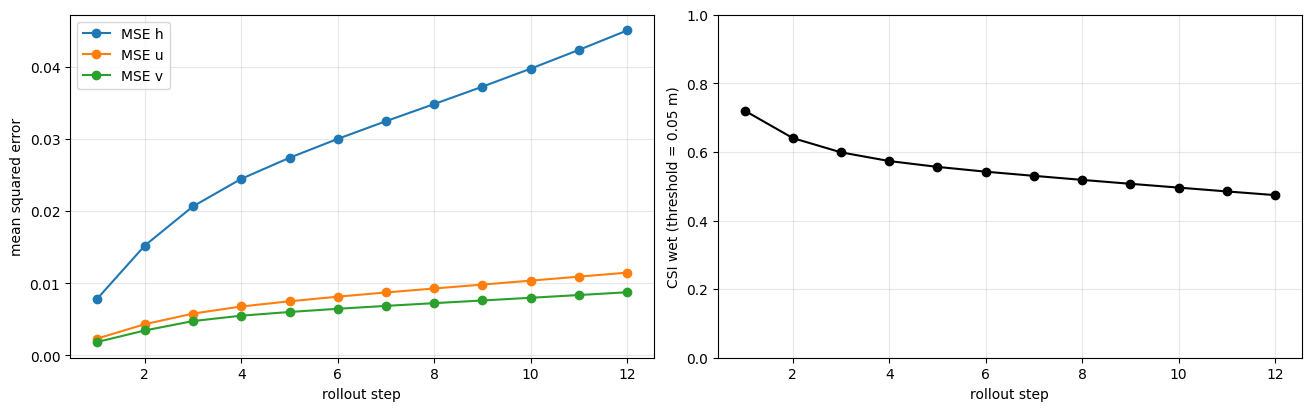

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

axes[0].plot(summary_df["step"], summary_df["mse_h"], marker="o", label="MSE h")
axes[0].plot(summary_df["step"], summary_df["mse_u"], marker="o", label="MSE u")
axes[0].plot(summary_df["step"], summary_df["mse_v"], marker="o", label="MSE v")
axes[0].set_xlabel("rollout step")
axes[0].set_ylabel("mean squared error")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(summary_df["step"], summary_df["csi_wet"], marker="o", color="black")
axes[1].set_xlabel("rollout step")
axes[1].set_ylabel(f"CSI wet (threshold = {WET_THRESHOLD_M:.2f} m)")
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(True, alpha=0.3)

plt.show()


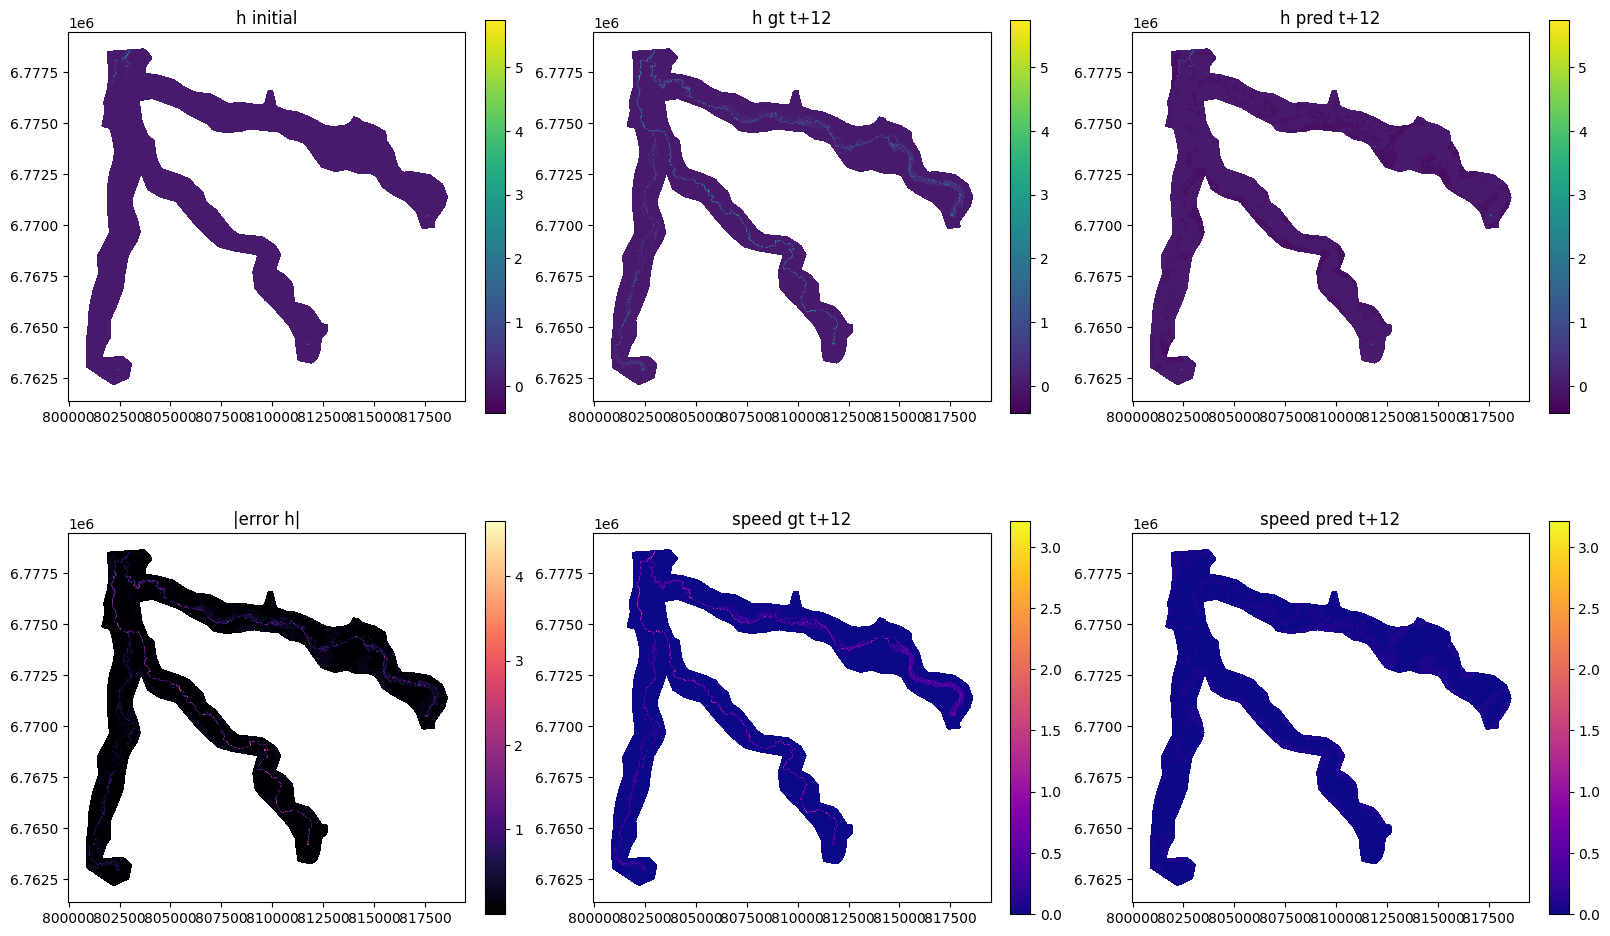

sequence index: 0
plot step: 12 (6.0 h)
{'mse_h': 0.09740927070379257, 'mse_u': 0.019931579008698463, 'mse_v': 0.01794532686471939, 'mae_h': 0.1094985380768776, 'mae_u': 0.04898647591471672, 'mae_v': 0.03207249939441681, 'csi_wet': 0.027101025569632002}


In [13]:
if not rollouts:
    raise ValueError("Aucun rollout disponible.")

rollout = rollouts[SEQUENCE_TO_PLOT]
plot_step = min(PLOT_STEP, len(rollout["pred_steps"]))
if plot_step < 1:
    raise ValueError("PLOT_STEP doit etre >= 1.")

initial = rollout["initial"]
pred = rollout["pred_steps"][plot_step - 1]
gt = rollout["gt_steps"][plot_step - 1]
metrics_row = rollout["metrics"].iloc[plot_step - 1]

h_vmin = float(min(initial[:, 0].min(), gt[:, 0].min(), pred[:, 0].min()))
h_vmax = float(max(initial[:, 0].max(), gt[:, 0].max(), pred[:, 0].max()))

speed_gt = np.linalg.norm(gt[:, 1:3], axis=1)
speed_pred = np.linalg.norm(pred[:, 1:3], axis=1)
speed_vmin = float(min(speed_gt.min(), speed_pred.min()))
speed_vmax = float(max(speed_gt.max(), speed_pred.max()))

fig, axes = plt.subplots(2, 3, figsize=FIGSIZE, constrained_layout=True)

plots = [
    ("h initial", initial[:, 0], "viridis", h_vmin, h_vmax),
    (f"h gt t+{plot_step}", gt[:, 0], "viridis", h_vmin, h_vmax),
    (f"h pred t+{plot_step}", pred[:, 0], "viridis", h_vmin, h_vmax),
    ("|error h|", np.abs(pred[:, 0] - gt[:, 0]), "magma", None, None),
    (f"speed gt t+{plot_step}", speed_gt, "plasma", speed_vmin, speed_vmax),
    (f"speed pred t+{plot_step}", speed_pred, "plasma", speed_vmin, speed_vmax),
]

for ax, (title, values, cmap, vmin, vmax) in zip(axes.ravel(), plots):
    artist = ax.tripcolor(triangulation, values, shading="flat", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_aspect("equal")
    fig.colorbar(artist, ax=ax, shrink=0.8)

plt.show()

print("sequence index:", rollout["sequence_index"])
print(f"plot step: {plot_step} ({0.5 * plot_step:.1f} h)")
print(metrics_row[["mse_h", "mse_u", "mse_v", "mae_h", "mae_u", "mae_v", "csi_wet"]].to_dict())


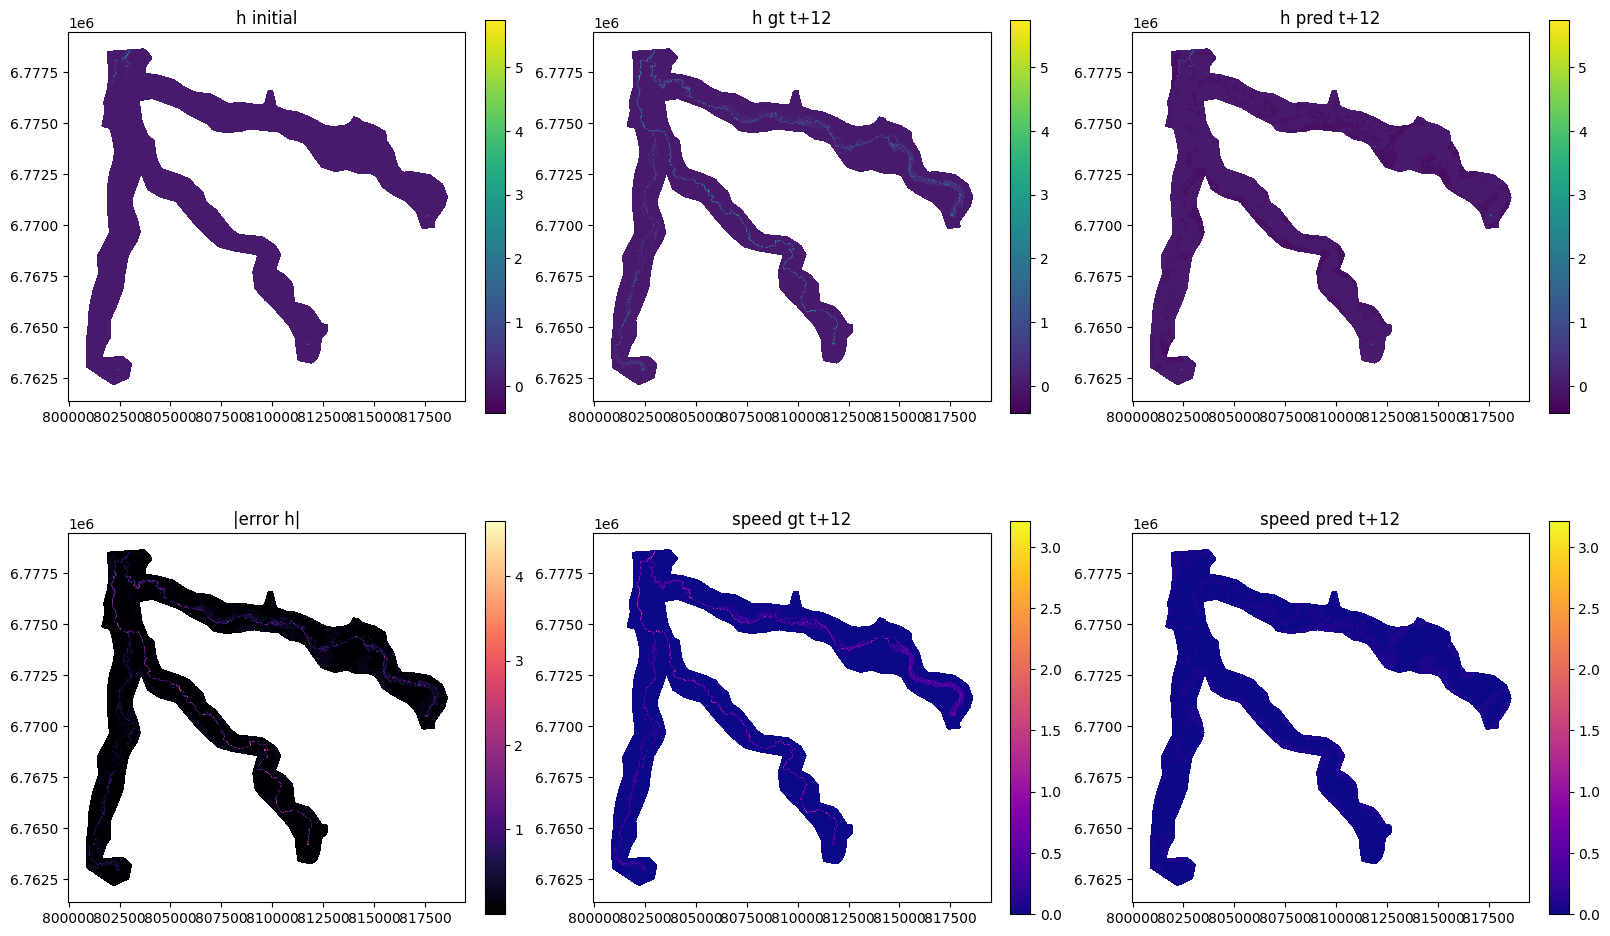

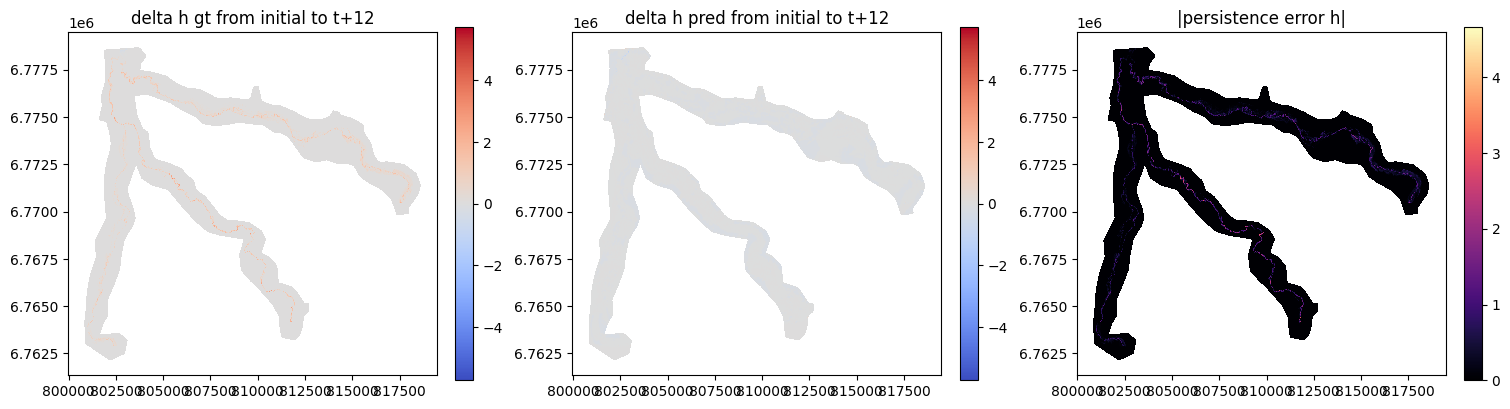

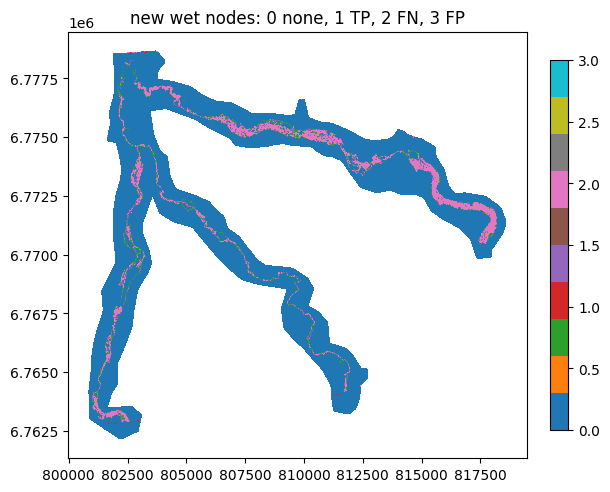

sequence index: 0
plot step: 12 (6.0 h)
{'mse_h': 0.09740927070379257, 'mse_u': 0.019931579008698463, 'mse_v': 0.01794532686471939, 'mae_h': 0.1094985380768776, 'mae_u': 0.04898647591471672, 'mae_v': 0.03207249939441681, 'csi_wet': 0.027101025569632002}

stationarity / propagation diagnostics:
{'mean_abs_move_gt_h': 0.06423261016607285, 'mean_abs_move_pred_h': 0.045859936624765396, 'mean_abs_move_persistence_h': 0.06423261016607285, 'motion_ratio_pred_vs_gt': 0.7139665740732155, 'initial_wet_frac': 0.003622364445599558, 'gt_wet_frac': 0.11591566225918586, 'pred_wet_frac': 0.003925581798295485, 'new_wet_gt_nodes': 20789, 'new_wet_pred_nodes': 96, 'front_csi': 0.0, 'front_tp': 0, 'front_fp': 96, 'front_fn': 20789}
interpretation: le niveau de mouvement de l'eau est du meme ordre que la verite terrain.


In [14]:
if not rollouts:
    raise ValueError("Aucun rollout disponible.")

rollout = rollouts[SEQUENCE_TO_PLOT]
plot_step = min(PLOT_STEP, len(rollout["pred_steps"]))
if plot_step < 1:
    raise ValueError("PLOT_STEP doit etre >= 1.")

initial = rollout["initial"]
pred = rollout["pred_steps"][plot_step - 1]
gt = rollout["gt_steps"][plot_step - 1]
metrics_row = rollout["metrics"].iloc[plot_step - 1]

initial_h = initial[:, 0]
pred_h = pred[:, 0]
gt_h = gt[:, 0]

delta_h_gt = gt_h - initial_h
delta_h_pred = pred_h - initial_h
delta_h_persist = initial_h - gt_h

h_vmin = float(min(initial_h.min(), gt_h.min(), pred_h.min()))
h_vmax = float(max(initial_h.max(), gt_h.max(), pred_h.max()))

delta_vmax = float(max(np.abs(delta_h_gt).max(), np.abs(delta_h_pred).max()))

speed_gt = np.linalg.norm(gt[:, 1:3], axis=1)
speed_pred = np.linalg.norm(pred[:, 1:3], axis=1)
speed_vmin = float(min(speed_gt.min(), speed_pred.min()))
speed_vmax = float(max(speed_gt.max(), speed_pred.max()))

initial_wet = initial_h >= WET_THRESHOLD_M
gt_wet = gt_h >= WET_THRESHOLD_M
pred_wet = pred_h >= WET_THRESHOLD_M

new_wet_gt = (~initial_wet) & gt_wet
new_wet_pred = (~initial_wet) & pred_wet

tp_front = int(np.sum(new_wet_gt & new_wet_pred))
fp_front = int(np.sum((~new_wet_gt) & new_wet_pred))
fn_front = int(np.sum(new_wet_gt & (~new_wet_pred)))
front_denom = tp_front + fp_front + fn_front
front_csi = float(tp_front / front_denom) if front_denom > 0 else float("nan")

mean_abs_move_gt = float(np.mean(np.abs(delta_h_gt)))
mean_abs_move_pred = float(np.mean(np.abs(delta_h_pred)))
mean_abs_move_persist = float(np.mean(np.abs(delta_h_persist)))
motion_ratio = float(mean_abs_move_pred / (mean_abs_move_gt + 1e-12))

fig, axes = plt.subplots(2, 3, figsize=FIGSIZE, constrained_layout=True)

plots = [
    ("h initial", initial_h, "viridis", h_vmin, h_vmax),
    (f"h gt t+{plot_step}", gt_h, "viridis", h_vmin, h_vmax),
    (f"h pred t+{plot_step}", pred_h, "viridis", h_vmin, h_vmax),
    ("|error h|", np.abs(pred_h - gt_h), "magma", None, None),
    (f"speed gt t+{plot_step}", speed_gt, "plasma", speed_vmin, speed_vmax),
    (f"speed pred t+{plot_step}", speed_pred, "plasma", speed_vmin, speed_vmax),
]

for ax, (title, values, cmap, vmin, vmax) in zip(axes.ravel(), plots):
    artist = ax.tripcolor(triangulation, values, shading="flat", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_aspect("equal")
    fig.colorbar(artist, ax=ax, shrink=0.8)

plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

delta_plots = [
    (f"delta h gt from initial to t+{plot_step}", delta_h_gt, "coolwarm", -delta_vmax, delta_vmax),
    (f"delta h pred from initial to t+{plot_step}", delta_h_pred, "coolwarm", -delta_vmax, delta_vmax),
    ("|persistence error h|", np.abs(delta_h_persist), "magma", None, None),
]

for ax, (title, values, cmap, vmin, vmax) in zip(axes.ravel(), delta_plots):
    artist = ax.tripcolor(triangulation, values, shading="flat", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_aspect("equal")
    fig.colorbar(artist, ax=ax, shrink=0.8)

plt.show()

front_labels = np.zeros_like(initial_h, dtype=np.int32)
front_labels[new_wet_gt & new_wet_pred] = 1
front_labels[new_wet_gt & (~new_wet_pred)] = 2
front_labels[(~new_wet_gt) & new_wet_pred] = 3

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
artist = ax.tripcolor(triangulation, front_labels, shading="flat", cmap="tab10", vmin=0, vmax=3)
ax.set_title("new wet nodes: 0 none, 1 TP, 2 FN, 3 FP")
ax.set_aspect("equal")
fig.colorbar(artist, ax=ax, shrink=0.8)
plt.show()

print("sequence index:", rollout["sequence_index"])
print(f"plot step: {plot_step} ({0.5 * plot_step:.1f} h)")
print(metrics_row[["mse_h", "mse_u", "mse_v", "mae_h", "mae_u", "mae_v", "csi_wet"]].to_dict())
print()

print("stationarity / propagation diagnostics:")
print({
    "mean_abs_move_gt_h": mean_abs_move_gt,
    "mean_abs_move_pred_h": mean_abs_move_pred,
    "mean_abs_move_persistence_h": mean_abs_move_persist,
    "motion_ratio_pred_vs_gt": motion_ratio,
    "initial_wet_frac": float(np.mean(initial_wet)),
    "gt_wet_frac": float(np.mean(gt_wet)),
    "pred_wet_frac": float(np.mean(pred_wet)),
    "new_wet_gt_nodes": int(np.sum(new_wet_gt)),
    "new_wet_pred_nodes": int(np.sum(new_wet_pred)),
    "front_csi": front_csi,
    "front_tp": tp_front,
    "front_fp": fp_front,
    "front_fn": fn_front,
})

if motion_ratio < 0.1:
    print("interpretation: le modele est presque stationnaire sur h a cet horizon.")
elif motion_ratio < 0.5:
    print("interpretation: le modele bouge un peu l'eau, mais beaucoup moins que la verite terrain.")
elif motion_ratio <= 1.5:
    print("interpretation: le niveau de mouvement de l'eau est du meme ordre que la verite terrain.")
else:
    print("interpretation: le modele semble sur-reactif sur h a cet horizon.")